# 03c - Baseline Evaluation
Porovnani vsech modelu (baseline + dummy). Tento notebook **nic netrenuuje** - cte vystupy z `031` a `032`.

In [14]:
import joblib
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')
results        = joblib.load('../results/baseline_results.pkl')
results_wo_gpa = joblib.load('../results/baseline_results_wo_gpa.pkl')
dummy_results  = joblib.load('../results/dummy_results.pkl')

print("Vysledky nacteny")

Vysledky nacteny


## Souhrnna srovnavaci tabulka (vcetne dummy)

In [15]:
rows = []
for name, res in dummy_results.items():
    rows.append({'Model': name, 'Typ': 'Dummy',    'Accuracy': res['accuracy'], 'ROC-AUC': res['roc_auc']})
for name, res in results.items():
    rows.append({'Model': name, 'Typ': 'Baseline', 'Accuracy': res['accuracy'], 'ROC-AUC': res['roc_auc']})

df_summary = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(df_summary.to_string(index=False))

                Model      Typ  Accuracy  ROC-AUC
    Gradient Boosting Baseline    0.7920 0.800920
  Logistic Regression Baseline    0.7480 0.798107
        Random Forest Baseline    0.7795 0.797189
        Decision Tree Baseline    0.7305 0.782398
   Dummy (stratified)    Dummy    0.6490 0.513342
Dummy (most_frequent)    Dummy    0.7645 0.500000


## Vliv absence GPA priznaku (ablacni studie)


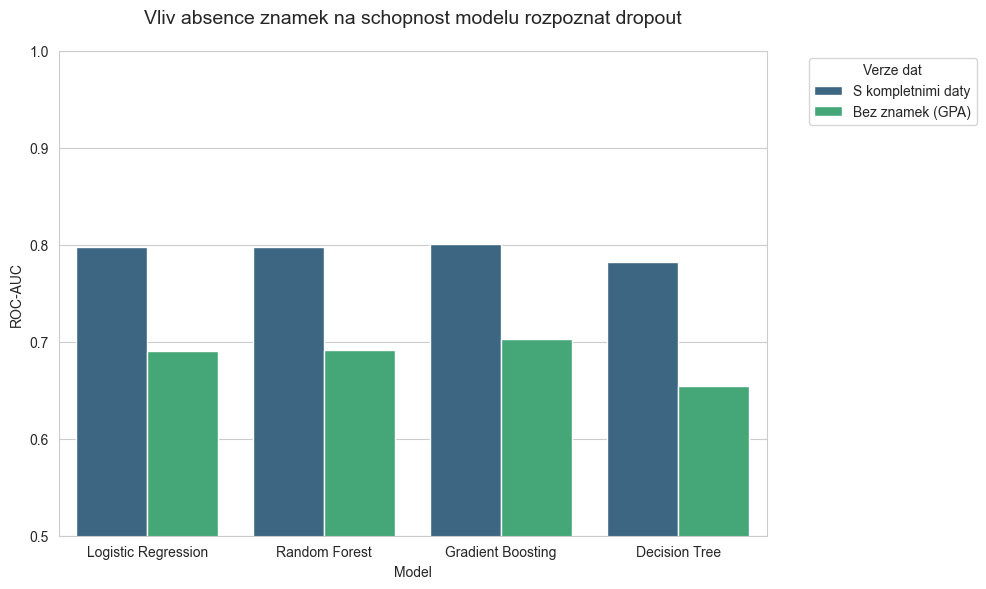

In [16]:
plot_data = []
for model_name in results.keys():
    plot_data.append({'Model': model_name, 'ROC-AUC': results[model_name]['roc_auc'],        'Typ': 'S kompletnimi daty'})
    if model_name in results_wo_gpa:
        plot_data.append({'Model': model_name, 'ROC-AUC': results_wo_gpa[model_name]['roc_auc'], 'Typ': 'Bez znamek (GPA)'})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(data=df_plot, x='Model', y='ROC-AUC', hue='Typ', palette='viridis')
plt.title('Vliv absence znamek na schopnost modelu rozpoznat dropout', fontsize=14, pad=20)
plt.ylim(0.5, 1.0)
plt.ylabel('ROC-AUC')
plt.legend(title='Verze dat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Feature Importance - Random Forest

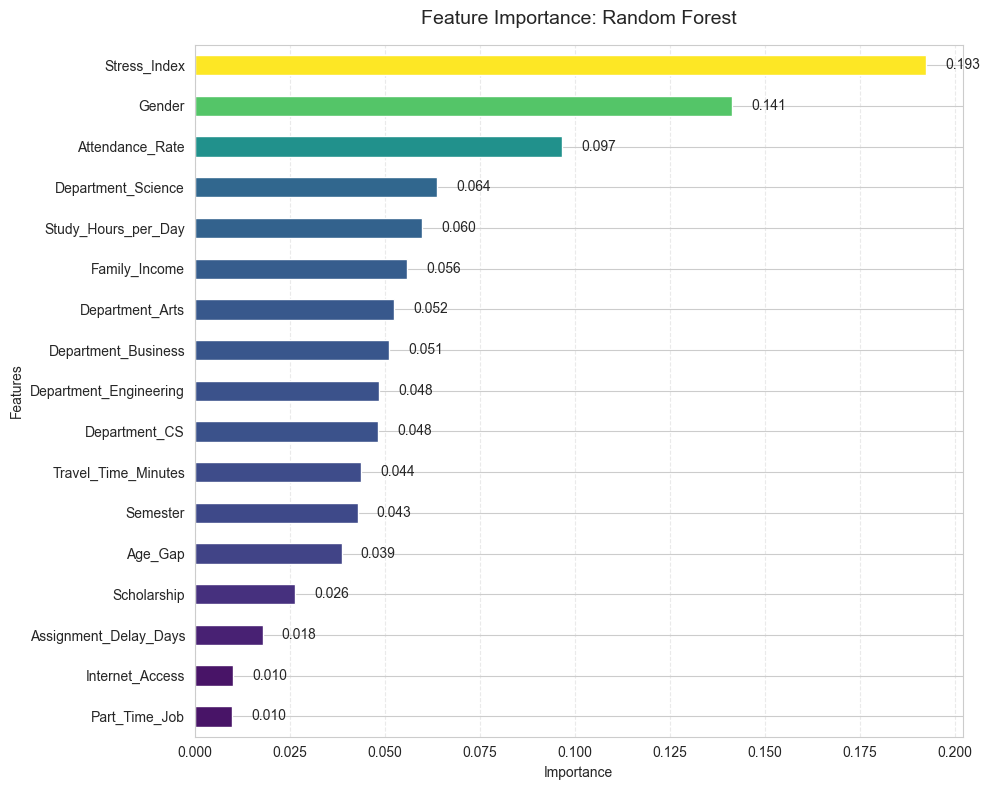

In [17]:
model_name  = 'Random Forest'
best_model  = results[model_name]['model']
importances = best_model.feature_importances_

if len(importances) == len(X_train_prep.columns):
    features = X_train_prep.columns
else:
    features = X_train_prep.drop(columns=['CGPA', 'GPA_trend'], errors='ignore').columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(feat_imp.values / max(feat_imp.values))
feat_imp.plot(kind='barh', color=colors)
plt.title(f'Feature Importance: {model_name}', fontsize=14, pad=15)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Confusion Matrix - Gradient Boosting


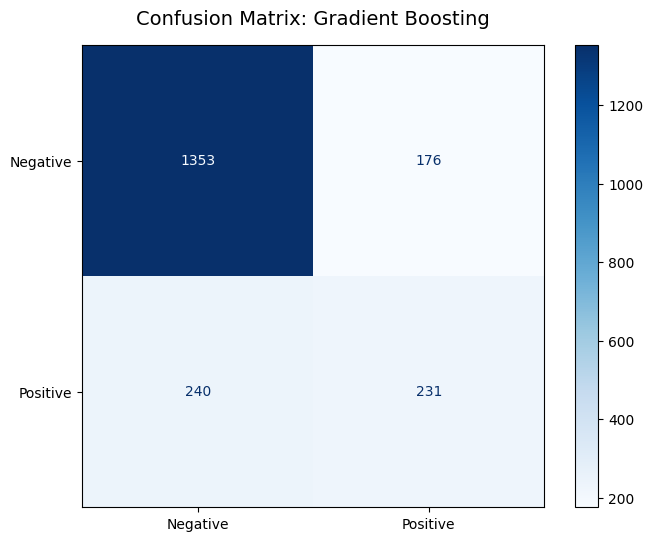

In [18]:
plt.style.use('default')
plt.rcParams.update({
    'text.color': 'black', 'axes.labelcolor': 'black',
    'xtick.color': 'black', 'ytick.color': 'black',
    'figure.facecolor': 'white', 'axes.facecolor': 'white'
})

model_name = 'Gradient Boosting'
y_pred_gb  = results[model_name]['y_pred']
cm         = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_xlabel('')
ax.set_ylabel('')
plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=15, color='black')
plt.grid(False)
plt.show()